#Hindi Embeddings Word2Vec

In [22]:
# Use the wget command to download the font file directly into the Colab environment.
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf

# Verify that the file has been downloaded
print("File downloaded! Checking contents:")
!ls NotoSansDevanagari-Regular.ttf


File downloaded! Checking contents:
NotoSansDevanagari-Regular.ttf


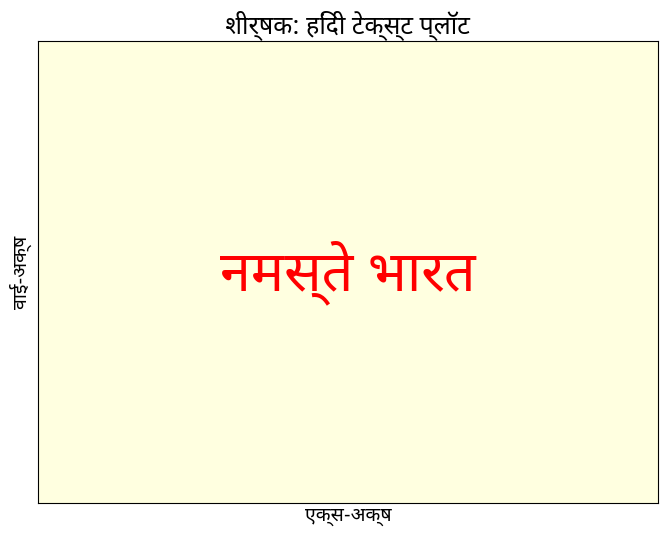

In [23]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np

# --- Configuration ---
# 1. Update this to the exact name of the .ttf file you downloaded and placed
#    in the same folder as your script.
font_filename = 'NotoSansDevanagari-Regular.ttf'
# If you used 'Mangal.ttf' from C:\Windows\Fonts, you would use that file's path.

try:
    # Load the font using its file path
    hindi_font_prop = FontProperties(fname=font_filename)

    # The Hindi phrase for "नमस्ते भारत" (Namaste Bharat / Hello India)
    hindi_phrase = "नमस्ते भारत"

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Add the text to the plot using the loaded font properties
    ax.text(
        x=0.5,
        y=0.5,
        s=hindi_phrase,
        fontproperties=hindi_font_prop, # <--- THIS IS KEY
        fontsize=40,
        ha='center',
        va='center',
        color='red'
    )

    # Adding a title and labels using the same font for consistency
    ax.set_title("शीर्षक: हिंदी टेक्स्ट प्लॉट", fontproperties=hindi_font_prop, fontsize=18)
    ax.set_xlabel("एक्स-अक्ष", fontproperties=hindi_font_prop, fontsize=14)
    ax.set_ylabel("वाई-अक्ष", fontproperties=hindi_font_prop, fontsize=14)

    # Set up the plot appearance
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(left=False, right=False, top=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_facecolor('lightyellow')
    plt.grid(False)

    plt.show()

except FileNotFoundError:
    # If the font file still can't be found, print a helpful error message
    print(f"\nFATAL ERROR: Font file not found.")
    print(f"Please check that '{font_filename}' is in the same directory as this Python script.")
    print("Or, replace 'font_filename' with the correct full path to your Hindi font file.")
    plt.show()

--- Setup ---
Setup complete.
--------------------------------------------------
🔄 Generating large, repetitive corpus...
✅ Corpus saved to 'hindi_corpus_final.txt'. Total lines: 579,000
✅ Word2Vec training corpus prepared. Estimated total words: 5,059,500

Data preparation time: 6.42 seconds
--------------------------------------------------
🚀 Training Word2Vec model with 100 dimensions...
✅ Model trained. Vocabulary size: 617 words.
Model training time: 57.98 seconds
--------------------------------------------------
🧠 Calculating Category Prototype Vectors...
✅ Calculated 12 prototypes.
--------------------------------------------------
Words found for TSNE: 103 / 240 selected words.
📏 Reducing dimensions using t-SNE...
📊 Generating t-SNE plot...


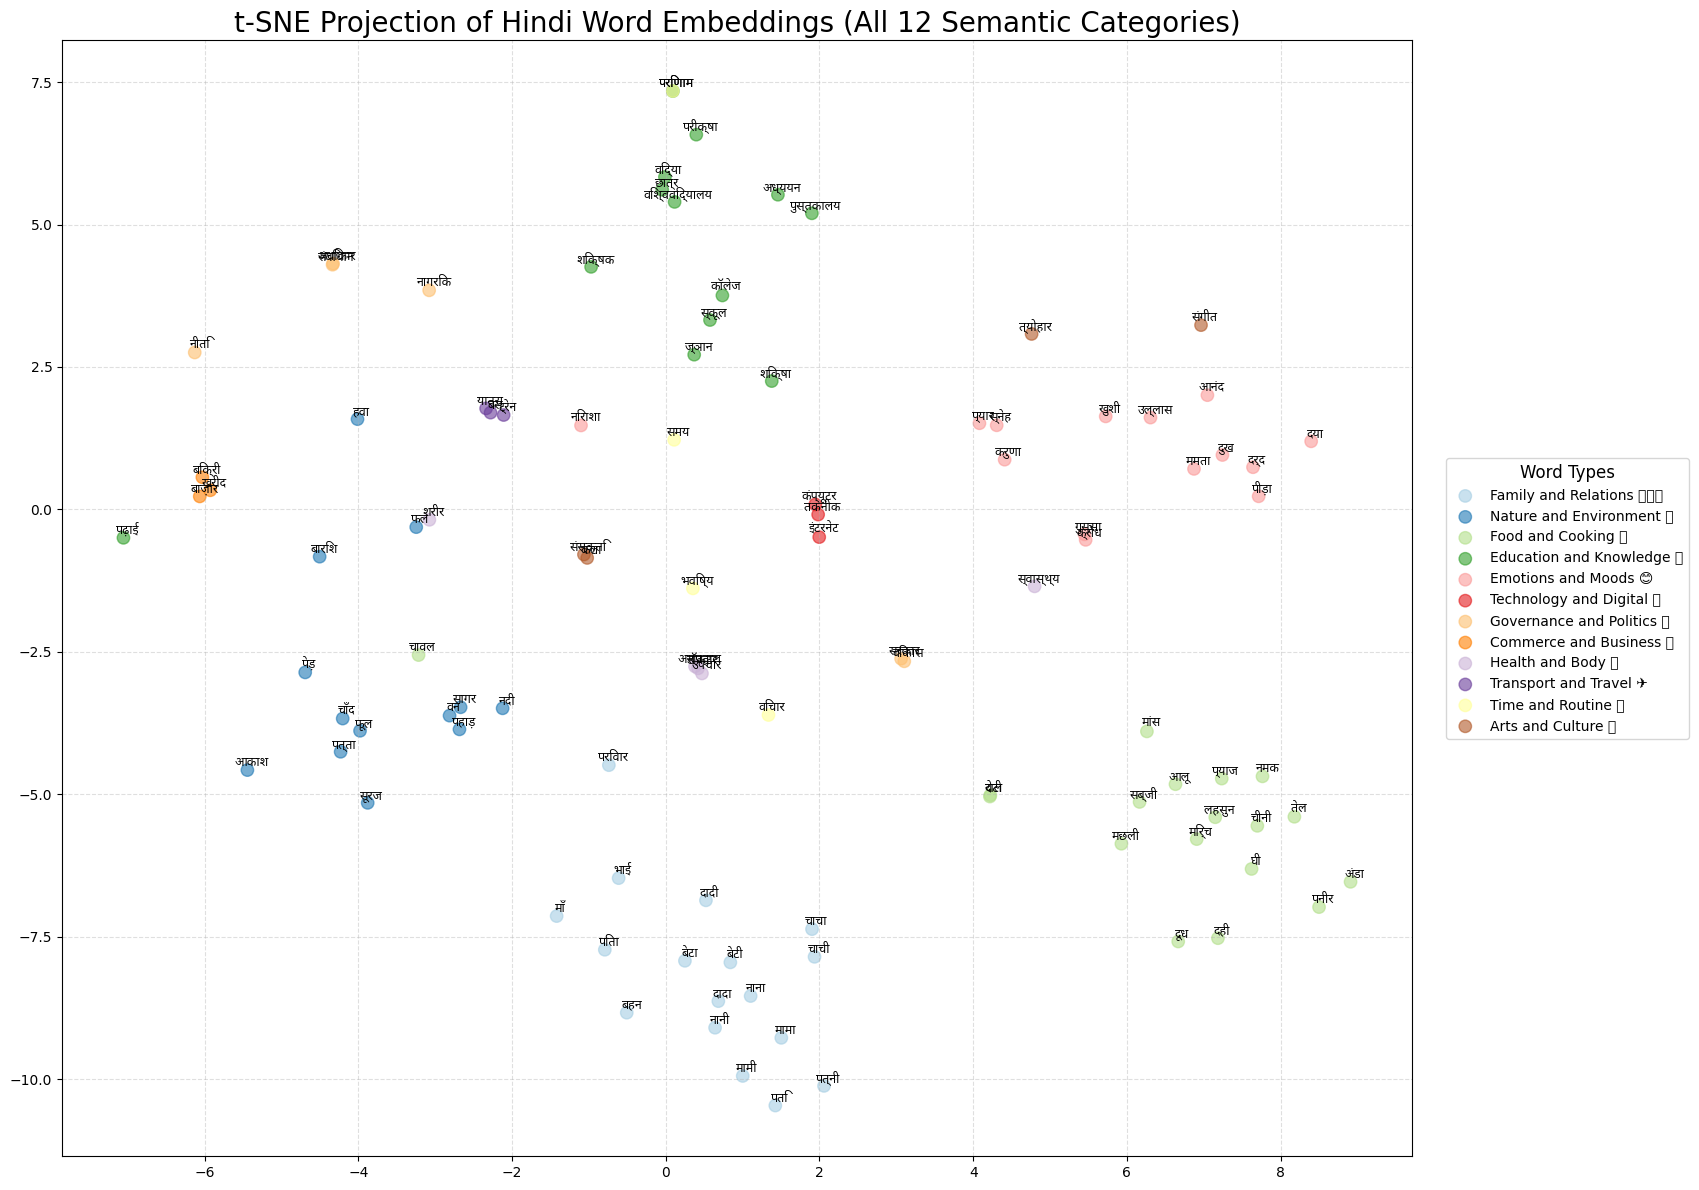

--------------------------------------------------
✅ Training, Plotting, and Prototypes Complete. Model is ready for testing.


In [70]:
# --- CELL 1: SETUP, TRAINING, AND PLOTTING (RUN ONCE) ---
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import time
import os
from collections import defaultdict

# --- CONFIGURATION ---
OUTPUT_CORPUS_PATH = 'hindi_corpus_final.txt'
DIMENSIONS = 100
N_WORDS_PER_TYPE = 20
N_CATEGORIES_TO_PLOT = 12
MIN_WORD_COUNT = 5
FALLBACK_REPEAT_FACTOR = 1500
FIXED_SENTENCES_RAW = ""
FONT_FILE = 'NotoSansDevanagari-Regular.ttf'

# --- SETUP: INSTALL LIBRARIES AND DOWNLOAD FONT ---
print("--- Setup ---")
!pip install -q gensim scikit-learn
print(f"Downloading required Hindi font: {FONT_FILE}")
!wget -q "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf" -O $FONT_FILE
print("Setup complete.")
print("-" * 50)

# --- INPUT DATA: Fallback Text (Corpus Source) ---
FALLBACK_BASE_TEXT = """
माँ, पिता, भाई और बहन मेरे परिवार के आधार हैं। परिवार के साथ समय बिताना जीवन का सबसे बड़ा सुख है।
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए। एक अच्छा शिक्षक समाज का भविष्य बनाता है।
पुस्तकें ज्ञान का भंडार हैं और हमारी सबसे अच्छी मित्र हैं। नदी, सागर, पहाड़ और वन प्रकृति की अद्भुत देन हैं।
सूरज की किरणें हर सुबह एक नई आशा लेकर आती हैं। हमें पर्यावरण की रक्षा करनी चाहिए और पेड़ लगाने चाहिए।
आज मैंने सुबह के नाश्ते में रोटी और दाल खाई। फल और सब्ज़ियाँ खाने से शरीर स्वस्थ रहता है।
प्यार, स्नेह और करुणा से ही रिश्ते मजबूत बनते हैं। क्रोध और गुस्सा हमारे स्वास्थ्य के लिए हानिकारक है।
सफलता प्राप्त करने के लिए धैर्य और परिश्रम आवश्यक है। संगीत सुनने से मन को शांति और आनंद मिलता है।
दीपावली और होली भारत के मुख्य त्योहार हैं। दिल्ली, मुंबई और कोलकाता भारत के बड़े शहर हैं।
हम सभी को हमेशा सच्चाई और ईमानदारी से काम करना चाहिए। कंप्यूटर और इंटरनेट आज की तकनीक का आधार हैं।
सरकार की योजनाएँ नागरिकों के विकास के लिए महत्वपूर्ण हैं। बाज़ार में खरीद और बिक्री रोज़ होती है।
अस्पताल में डॉक्टर मरीजों का उपचार करते हैं। ट्रेन और बस से यात्रा करना सुविधाजनक है।
समय सबसे मूल्यवान है, इसका सदुपयोग करना चाहिए। कला और संस्कृति समाज को जीवंत बनाते हैं।
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है
सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है
माँ ने स्वादिष्ट दाल बनाई है
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं
शिक्षा हर नागरिक का अधिकार है
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है
सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है
माँ ने स्वादिष्ट दाल बनाई है
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं
शिक्षा हर नागरिक का अधिकार है
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है
सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है
माँ ने स्वादिष्ट दाल बनाई है
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं
शिक्षा हर नागरिक का अधिकार है
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है। सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है।
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है। माँ ने स्वादिष्ट दाल बनाई है।
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं। शिक्षा हर नागरिक का अधिकार है।
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए। एक शिक्षक समाज का भविष्य बनाता है।
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं। प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं।
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है। पेड़-पौधे हमें ऑक्सीजन देते हैं।
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं। खुशी और दुःख जीवन के दो पहलू हैं।
क्रोध और गुस्सा सेहत के लिए हानिकारक है। प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं।
हमेशा उदारता और करुणा का भाव रखें।
माँ पिता बेटा बेटी भाई बहन दादा दादी नाना नानी चाचा चाची मामा मामी पति पत्नी।
नदी सागर पहाड़ वन पेड़ फूल पत्ता चावल गेहूं मक्का गन्ना कपास सूरज चाँद तारा आकाश।
रोटी मछली मांस दाल सब्जी आलू प्याज लहसुन मिर्च नमक चीनी तेल घी दूध दही पनीर अंडा।
स्कूल कॉलेज विश्वविद्यालय शिक्षक छात्र छात्रा शिक्षा ज्ञान विद्या अध्ययन परीक्षा परिणाम।
प्यार स्नेह ममता दया करुणा सहानुभूति आनंद खुशी उल्लास दुख दर्द पीड़ा क्रोध गुस्सा।
मैं भारत का नागरिक हूँ और मुझे इस पर गर्व है।
हिंदी भाषा हमारी राष्ट्रभाषा है और यह बहुत मधुर है।
दिल्ली भारत की राजधानी है, जहाँ कई ऐतिहासिक इमारतें हैं।
मुंबई को भारत की आर्थिक राजधानी भी कहा जाता है।
गंगा नदी उत्तर भारत की सबसे पवित्र और लंबी नदी है।
ताजमहल आगरा में स्थित एक विश्व प्रसिद्ध प्रेम का प्रतीक है।
हमारा संविधान देश के सभी नागरिकों को समान अधिकार देता है।
हर साल 15 अगस्त को स्वतंत्रता दिवस मनाया जाता है।
मेरा परिवार मेरे लिए सबसे महत्वपूर्ण है, हम एक-दूसरे का समर्थन करते हैं।
माँ का प्यार दुनिया में सबसे अनमोल होता है।
पिताजी रोज़ सुबह पार्क में टहलने जाते हैं।
मेरी बड़ी बहन एक स्कूल में शिक्षक हैं।
मेरा छोटा भाई अभी कॉलेज में पढ़ रहा है।
दादी माँ शाम को हमें रोचक कहानियाँ सुनाती हैं।
चाचा और चाची पिछले सप्ताह हमसे मिलने आए थे।
परिवार के साथ समय बिताना मुझे बहुत पसंद है।
बच्चों को अपने माता-पिता की आज्ञा माननी चाहिए।
रिश्ते प्रेम और विश्वास की नींव पर टिके होते हैं।
हम सब मिलकर हर त्योहार धूमधाम से मनाते हैं।
परिवार में अनुशासन और प्रेम दोनों जरूरी हैं।
सूरज की किरणें सुबह उठकर नई ऊर्जा देती हैं।
रात में चाँद और तारे आसमान में टिमटिमाते हैं।
पेड़ हमारे पर्यावरण को स्वच्छ रखने में मदद करते हैं।
बारिश के मौसम में धरती पर हरियाली छा जाती है।
नदियाँ पर्वतों से निकलकर मैदानों में बहती हैं।
समुद्र का किनारा शांत और सुंदर होता है।
जंगल में तरह-तरह के जानवर और पक्षी रहते हैं।
हमें पानी की बर्बादी नहीं करनी चाहिए।
हवा में प्रदूषण कम करना हम सबकी जिम्मेदारी है。
पहाड़ों पर अक्सर बर्फबारी होती रहती है।
धरती की सुरक्षा के लिए पेड़ लगाना आवश्यक है।
फूलों की सुगंध मन को प्रसन्न कर देती है।
जानवरों के प्रति दया का भाव रखना चाहिए।
मौसम का बदलाव प्रकृति का एक चक्र है।
सफाई बनाए रखने से बीमारियाँ दूर रहती हैं।
आज मैंने दोपहर के भोजन में रोटी और दाल खाई।
सब्जियों का सेवन स्वास्थ्य के लिए बहुत लाभकारी होता है।
फल खाने से शरीर को तुरंत ऊर्जा मिलती है।
दूध और दही प्रोटीन के अच्छे स्रोत हैं।
भारत में चावल और गेहूँ मुख्य अनाज हैं।
मीठा खाने में मिठाई और जलेबी बच्चों को बहुत पसंद है।
खाना हमेशा समय पर और संतुलित खाना चाहिए।
चाय और कॉफी का अधिक सेवन हानिकारक हो सकता है।
हरी पत्तेदार सब्ज़ियाँ आयरन से भरपूर होती हैं।
अंडे और मांस में भी उच्च मात्रा में प्रोटीन होता है।
सलाद और सूप पाचन तंत्र को स्वस्थ रखते हैं।
रसोई में माँ ने गरमा गरम पकवान बनाए।
बाज़ार में ताज़ी मछलियाँ उपलब्ध थीं।
पानी पीने से शरीर हाइड्रेटेड रहता है।
विद्यालय ज्ञान का मंदिर होता है।
शिक्षक हमारे जीवन को सही दिशा देते हैं।
हमें स्कूल में अनुशासन का पालन करना चाहिए।
पढ़ाई से ही जीवन में सफलता प्राप्त होती है।
गणित और विज्ञान मेरे पसंदीदा विषय हैं।
किताबें पढ़कर हमें नई जानकारी मिलती है।
कॉलेज में उच्च शिक्षा प्राप्त करने का अवसर मिलता है।
परीक्षाएँ हमारे ज्ञान का मूल्यांकन करती हैं।
विद्यार्थियों को हमेशा जिज्ञासु रहना चाहिए।
पुस्तकालय में शांत माहौल में अध्ययन करना चाहिए।
नैतिक शिक्षा हमें अच्छे संस्कार सिखाती है।
हर विषय को ध्यान से समझना महत्वपूर्ण है।
अच्छे नोट्स बनाने से पढ़ाई आसान हो जाती है।
प्रतियोगिता में भाग लेने से आत्मविश्वास बढ़ता है।
इंटरनेट आज शिक्षा का एक बड़ा साधन है।
मन प्रसन्न हो तो हर काम आसान लगता है।
खुशी और उल्लास जीवन को रंगीन बनाते हैं।
प्यार और स्नेह हर रिश्ते को मजबूत बनाते हैं।
गुस्सा करने से हमेशा बचना चाहिए।
दूसरों की सहायता करने से मन को शांति मिलती है।
धैर्य और संयम से हर समस्या का हल निकल सकता है।
सकारात्मक सोच जीवन में प्रगति लाती है।
दुःख के समय हमें हिम्मत नहीं हारनी चाहिए।
संगीत सुनने से तनाव दूर होता है।
ईमानदारी सबसे अच्छी नीति है।
सच्चाई हमेशा जीतती है, भले ही देर लगे।
मित्रों का साथ जीवन में सुखद अनुभव देता है।
आत्मविश्वास से हम बड़ी से बड़ी चुनौती का सामना कर सकते हैं।
मेहनत करने वालों की कभी हार नहीं होती।
हमें हर पल को पूरी तरह से जीना चाहिए।
सफलता के लिए लक्ष्य निर्धारित करना जरूरी है।
कृतज्ञता का भाव मन को विनम्र बनाता है।
सपने देखो और उन्हें पूरा करने के लिए प्रयास करो।
जीवन में संतुलन बनाए रखना आवश्यक है।
योग और व्यायाम शरीर को स्वस्थ रखते हैं।
सुबह जल्दी उठना अच्छी आदत है।
हर दिन नई चीजें सीखने का प्रयास करें।
हमें अपने समय का सदुपयोग करना चाहिए।
अच्छे कर्मों से समाज में सम्मान मिलता है।
बड़ों का आदर करना हमारी संस्कृति है।
दूसरों की भावनाओं का सम्मान करना चाहिए।
जीवन एक सफर है, इसका आनंद लो।
आज का काम कल पर मत टालो।
हमेशा सच बोलना चाहिए।
स्वच्छता ईश्वरत्व के निकट है।
सादगी जीवन को सुंदर बनाती है।
संघर्ष के बिना कोई सफलता नहीं मिलती।
आपसी सहयोग से हर काम संभव है।
आशा के साथ आगे बढ़ो।
ईश्वर पर विश्वास रखो।
जीवन में विनम्रता आवश्यक है।
मैं भारत का नागरिक हूँ और मुझे इस देश पर गर्व है।
हिंदी भाषा बहुत मधुर और हमारी संस्कृति का अभिन्न अंग है।
दिल्ली भारत की ऐतिहासिक और राजनीतिक राजधानी है।
मुंबई को देश की आर्थिक शक्ति का केंद्र माना जाता है।
गंगा नदी भारत की मुख्य जीवन रेखा और पूजनीय नदी है।
हर साल हम सभी स्वतंत्रता दिवस और गणतंत्र दिवस मनाते हैं।
मेरा परिवार मेरी सबसे बड़ी ताकत और सहारा है।
माँ, पिता, भाई, बहन—हम सब एक-दूसरे से बहुत प्रेम करते हैं।
दादी माँ की कहानियाँ हमेशा ज्ञान और शिक्षा से भरी होती हैं।
चाचा और मामीजी अक्सर त्योहारों पर हमसे मिलने आते हैं।
बच्चों को बड़ों का सम्मान करना और उनकी बात माननी चाहिए।
स्कूल जाकर हमें अच्छी शिक्षा और ज्ञान प्राप्त होता है।
शिक्षक हमें केवल पढ़ाते नहीं, बल्कि अच्छे संस्कार भी सिखाते हैं।
गणित और विज्ञान जैसे विषय सीखने में बहुत रोचक होते हैं।
किताबें ज्ञान का सबसे बड़ा स्रोत हैं, हमें रोज़ पढ़ना चाहिए।
पढ़ाई के साथ-साथ खेलकूद भी जीवन में बहुत जरूरी है।
हमें हमेशा अपने स्कूल में अनुशासन बनाए रखना चाहिए।
सूरज की किरणें हर सुबह एक नई शुरुआत का संकेत देती हैं।
नदियाँ जीवन के लिए आवश्यक जल प्रदान करती हैं।
पेड़-पौधे पर्यावरण को स्वच्छ और हरा-भरा रखते हैं।
हवा और पानी के बिना जीवन संभव नहीं है।
बारिश का मौसम धरती पर हरियाली और ठंडक लाता है।
हमें प्रकृति का सम्मान करना और उसकी रक्षा करनी चाहिए।
जंगल में कई प्रकार के जानवर और पक्षी निवास करते हैं।
सफाई और स्वच्छता बनाए रखना हम सबकी जिम्मेदारी है।
रोटी, दाल, चावल और सब्ज़ी भारतीय भोजन का मुख्य हिस्सा हैं।
फल और दूध पीने से हमारा शरीर स्वस्थ और मजबूत बनता है।
हरी सब्ज़ियों का सेवन स्वास्थ्य के लिए बहुत लाभकारी है।
भोजन हमेशा समय पर और संतुलित खाना चाहिए।
चाय और कॉफी का सेवन संयम से करना उचित होता है।
प्यार, स्नेह और करुणा मानवीय भावनाओं के प्रतीक हैं।
खुशी के पल जीवन को सुंदर और यादगार बनाते हैं।
दुःख और निराशा से लड़कर हमें आगे बढ़ना चाहिए।
धैर्य और आत्मविश्वास सफलता की कुंजी हैं।
गुस्सा करना सेहत और रिश्तों दोनों के लिए हानिकारक है।
सकारात्मक सोच से जीवन में हर मुश्किल आसान हो जाती है।
मित्रों के साथ समय बिताना एक सुखद अनुभव होता है।
हमें हमेशा सच्चाई और ईमानदारी का पालन करना चाहिए।
अनुभव से व्यक्ति को सही ज्ञान और समझ मिलती है।
मेहनत और लगन से हर लक्ष्य को प्राप्त किया जा सकता है।
संगीत सुनना मन को शांत और प्रसन्न करता है।
हर्ष और उल्लास हर त्योहार को खास बनाते हैं।
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है
सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है
माँ ने स्वादिष्ट दाल बनाई है
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं
शिक्षा हर नागरिक का अधिकार है
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है
सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है
माँ ने स्वादिष्ट दाल बनाई है
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं
शिक्षा हर नागरिक का अधिकार है
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है
सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है
माँ ने स्वादिष्ट दाल बनाई है
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं
शिक्षा हर नागरिक का अधिकार है
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है। सूर्य पूर्व दिशा में उगता है और पश्चिम में डूब जाता है।
मेरा परिवार एक साथ भोजन करने की तैयारी कर रहा है। माँ ने स्वादिष्ट दाल बनाई है।
भाई और बहनें मिलकर घर के काम में हाथ बँटा रहे हैं। शिक्षा हर नागरिक का अधिकार है।
हमें स्कूल और कॉलेज जाकर ज्ञान अर्जित करना चाहिए। एक शिक्षक समाज का भविष्य बनाता है।
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं। प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं।
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है। पेड़-पौधे हमें ऑक्सीजन देते हैं।
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं। खुशी और दुःख जीवन के दो पहलू हैं।
क्रोध और गुस्सा सेहत के लिए हानिकारक है। प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं।
हमेशा उदारता और करुणा का भाव रखें।
माँ पिता बेटा बेटी भाई बहन दादा दादी नाना नानी चाचा चाची मामा मामी पति पत्नी।
नदी सागर पहाड़ वन पेड़ फूल पत्ता चावल गेहूं मक्का गन्ना कपास सूरज चाँद तारा आकाश।
रोटी मछली मांस दाल सब्जी आलू प्याज लहसुन मिर्च नमक चीनी तेल घी दूध दही पनीर अंडा।
स्कूल कॉलेज विश्वविद्यालय शिक्षक छात्र छात्रा शिक्षा ज्ञान विद्या अध्ययन परीक्षा परिणाम।
प्यार स्नेह ममता दया करुणा सहानुभूति आनंद खुशी उल्लास दुख दर्द पीड़ा क्रोध गुस्सा।
मैं भारत का नागरिक हूँ और मुझे इस पर गर्व है।
हिंदी भाषा हमारी राष्ट्रभाषा है और यह बहुत मधुर है।
दिल्ली भारत की राजधानी है, जहाँ कई ऐतिहासिक इमारतें हैं।
मुंबई को भारत की आर्थिक राजधानी भी कहा जाता है।
गंगा नदी उत्तर भारत की सबसे पवित्र और लंबी नदी है।
ताजमहल आगरा में स्थित एक विश्व प्रसिद्ध प्रेम का प्रतीक है।
हमारा संविधान देश के सभी नागरिकों को समान अधिकार देता है।
हर साल 15 अगस्त को स्वतंत्रता दिवस मनाया जाता है।
मेरा परिवार मेरे लिए सबसे महत्वपूर्ण है, हम एक-दूसरे का समर्थन करते हैं।
माँ का प्यार दुनिया में सबसे अनमोल होता है।
पिताजी रोज़ सुबह पार्क में टहलने जाते हैं।
मेरी बड़ी बहन एक स्कूल में शिक्षक हैं।
मेरा छोटा भाई अभी कॉलेज में पढ़ रहा है।
दादी माँ शाम को हमें रोचक कहानियाँ सुनाती हैं।
चाचा और चाची पिछले सप्ताह हमसे मिलने आए थे।
परिवार के साथ समय बिताना मुझे बहुत पसंद है।
बच्चों को अपने माता-पिता की आज्ञा माननी चाहिए।
रिश्ते प्रेम और विश्वास की नींव पर टिके होते हैं।
हम सब मिलकर हर त्योहार धूमधाम से मनाते हैं।
परिवार में अनुशासन और प्रेम दोनों जरूरी हैं।
सूरज की किरणें सुबह उठकर नई ऊर्जा देती हैं।
रात में चाँद और तारे आसमान में टिमटिमाते हैं।
पेड़ हमारे पर्यावरण को स्वच्छ रखने में मदद करते हैं।
बारिश के मौसम में धरती पर हरियाली छा जाती है।
नदियाँ पर्वतों से निकलकर मैदानों में बहती हैं।
समुद्र का किनारा शांत और सुंदर होता है।
जंगल में तरह-तरह के जानवर और पक्षी रहते हैं।
हमें पानी की बर्बादी नहीं करनी चाहिए।
हवा में प्रदूषण कम करना हम सबकी जिम्मेदारी है।
पहाड़ों पर अक्सर बर्फबारी होती रहती है।
धरती की सुरक्षा के लिए पेड़ लगाना आवश्यक है।
फूलों की सुगंध मन को प्रसन्न कर देती है।
जानवरों के प्रति दया का भाव रखना चाहिए।
मौसम का बदलाव प्रकृति का एक चक्र है।
सफाई बनाए रखने से बीमारियाँ
हमारे निर्णय हमारे भविष्य की दिशा तय करते हैं।
विद्यालय में मित्र बनाना और उनके साथ पढ़ना अच्छा लगता है।
अच्छे विचार मन को सकारात्मक ऊर्जा देते हैं।
समुद्र में कई प्रकार की मछलियाँ और जीव-जंतु पाए जाते हैं।
गर्मी के मौसम में ठंडे फल और शरबत राहत देते हैं।
एक शिक्षक समाज का भविष्य बनाता है
पुस्तकें हमारी सबसे अच्छी मित्र होती हैं
प्रकृति में नदी, सागर, पहाड़ और वन शामिल हैं
हरियाली हमारे पर्यावरण के लिए बहुत ज़रूरी है
पेड़-पौधे हमें ऑक्सीजन देते हैं
किसान खेत में गेहूँ, चावल और गन्ना उगाते हैं
खुशी और दुःख जीवन के दो पहलू हैं
क्रोध और गुस्सा सेहत के लिए हानिकारक है
प्यार और स्नेह से ही रिश्ते मजबूत बनते हैं
हमेशा उदारता और करुणा का भाव रखें
आज का दिन बेहद रोमांचक है

पतझड़ के मौसम में पेड़ अपने पुराने पत्ते गिरा देते हैं।
वसंत ऋतु में चारों ओर फूल खिलते हैं और खुशबू फैलती है।
हमें हमेशा विनम्रता और आदर का भाव रखना चाहिए।
"""

# --- UTILITY FUNCTIONS ---

def get_all_categories_internal(n_words=N_WORDS_PER_TYPE):
    # Defining the full category dictionary
    full_categories = {
        'Family and Relations 🧑‍🤝‍🧑': [ 'माँ', 'पिता', 'बेटा', 'बेटी', 'भाई', 'बहन', 'दादा', 'दादी', 'नाना', 'नानी', 'चाचा', 'चाची', 'मामा', 'मामी', 'पति', 'पत्नी', 'पुत्र', 'पोता', 'परिवार', 'दोस्त', ],
        'Nature and Environment 🌳': [ 'नदी', 'सागर', 'पहाड़', 'वन', 'पेड़', 'फूल', 'पत्ता', 'डाली', 'जड़', 'फल', 'सूरज', 'चाँद', 'tara', 'आकाश', 'बादल', 'बारिश', 'हवा', 'पवन', 'प्रकाश', 'पृथ्वी', ],
        'Food and Cooking 🍽️': [ 'चावल', 'रोटी', 'मछली', 'मांस', 'दाल', 'सब्जी', 'आलू', 'प्याज', 'लहसुन', 'अदरक', 'हल्दी', 'मिर्च', 'नमक', 'चीनी', 'तेल', 'घी', 'दूध', 'दही', 'पनीर', 'अंडा', 'गेहूँ', ],
        'Education and Knowledge 📚': [ 'स्कूल', 'कॉलेज', 'विश्वविद्यालय', 'शिक्षक', 'छात्र', 'शिक्षा', 'ज्ञान', 'विद्या', 'अध्यापन', 'पढ़ाई', 'अध्ययन', 'शोध', 'परीक्षा', 'नंबर', 'परिणाम', 'किताब', 'पुस्तक', 'कॉपी', 'कलम', 'पुस्तकालय', ],
        'Emotions and Moods 😊': [ 'प्यार', 'स्नेह', 'ममता', 'दया', 'करुणा', 'आनंद', 'खुशी', 'उल्लास', 'उत्साह', 'आश्चर्य', 'दुख', 'दर्द', 'पीड़ा', 'शोक', 'निराशा', 'क्रोध', 'गुस्सा', 'झुंझलाहट', 'चिंता', 'परेशानी', ],
        'Technology and Digital 💻': [ 'इंटरनेट', 'कंप्यूटर', 'मोबाइल', 'सॉफ्टवेयर', 'वेबसाइट', 'सूचना', 'प्रौद्योगिकी', 'डिजिटल', 'नेटवर्क', 'डेटा', 'उपकरण', 'वायरलेस', 'ईमेल', 'कनेक्शन', 'स्क्रीन', 'एप्लिकेशन', 'रोबोट', 'सर्वर', 'कोड', 'तकनीक', ],
        'Governance and Politics 🏛️': [ 'सरकार', 'शासन', 'अधिकारी', 'कानून', 'संविधान', 'न्याय', 'चुनाव', 'मतदान', 'नागरिक', 'विकास', 'नीति', 'बजट', 'मंत्रालय', 'प्रशासन', 'अर्थव्यवस्था', 'राज्य', 'संसद', 'अधिकार', 'कर्तव्य', 'योजना', ],
        'Commerce and Business 💰': [ 'व्यापार', 'बाज़ार', 'दुकान', 'ग्राहक', 'विक्रेता', 'खरीद', 'बिक्री', 'पैसा', 'धन', 'आय', 'ख़र्च', 'मुनाफ़ा', 'नुकसान', 'कंपनी', 'निवेश', 'बैंक', 'ऋण', 'वैट', 'टैक्स', 'अर्थ', ],
        'Health and Body 💊': [ 'शरीर', 'स्वास्थ्य', 'बीमारी', 'दवा', 'उपचार', 'डॉक्टर', 'अस्पताल', 'नब्ज़', 'रक्त', 'हड्डी', 'मांसपेशी', 'आँख', 'कान', 'नाक', 'दाँत', 'पेट', 'सिर', 'ज्वर', 'पसीना', 'श्वास', ],
        'Transport and Travel ✈️': [ 'सफ़र', 'यात्रा', 'ट्रेन', 'बस', 'कार', 'हवाईजहाज', 'बंदरगाह', 'स्टेशन', 'सड़क', 'पुल', 'रेल', 'यात्री', 'चालक', 'टिकट', 'माल', 'पेट्रोल', 'किराया', 'रास्ता', 'गति', 'दूरी', ],
        'Time and Routine ⏰': [ 'समय', 'काल', 'भूतकाल', 'वर्तमान', 'भविष्य', 'सत्य', 'झूठ', 'कल्पना', 'वास्तविकता', 'सिद्धांत', 'तर्क', 'विवेक', 'विचार', 'संकल्प', 'धारणा', 'मूल्य', 'पहचान', 'अस्तित्व', 'उद्देश्य', 'परिणाम', 'सुबह', 'शाम', 'दिन', 'रात', 'आज', 'कल', ], # <-- UPDATED CATEGORY
        'Arts and Culture 🎭': [ 'कला', 'संस्कृति', 'संगीत', 'नृत्य', 'नाटक', 'फ़िल्म', 'चित्रकला', 'मूर्ति', 'शिल्प', 'रंग', 'गायक', 'अभिनेता', 'कवि', 'लेखक', 'साहित्य', 'कहानी', 'कविता', 'त्योहार', 'मेला', 'प्रदर्शन', ]
    }
    return {k: v[:n_words] for k, v in full_categories.items()}


def clean_fixed_sentences(raw_text):
    lines = raw_text.strip().split('\n')
    cleaned_sentences = []
    for line in lines:
        clean_line = line.strip()
        if clean_line.startswith('"') and clean_line.endswith('"'): clean_line = clean_line[1:-1]
        if clean_line.endswith(','): clean_line = clean_line[:-1]
        final_sentence = clean_line.strip()
        if final_sentence: cleaned_sentences.append(final_sentence)
    return cleaned_sentences

def generate_and_merge_corpus_internal(fixed_raw_text, fallback_base_text, repeat_factor):
    print("🔄 Generating large, repetitive corpus...")
    fixed_sentences = clean_fixed_sentences(fixed_raw_text)
    repeated_corpus = []
    base_sentences = [s.strip() for block in fallback_base_text.split('\n')
                      for s in block.split('।') if s.strip()]
    for _ in range(repeat_factor): repeated_corpus.extend(base_sentences)
    merged_corpus = '\n'.join(fixed_sentences) + '\n' + '\n'.join(repeated_corpus)
    with open(OUTPUT_CORPUS_PATH, 'w', encoding='utf-8') as f: f.write(merged_corpus)
    print(f"✅ Corpus saved to '{OUTPUT_CORPUS_PATH}'. Total lines: {len(fixed_sentences) + len(repeated_corpus):,}")

    sentences_for_w2v = []
    word_count = 0
    with open(OUTPUT_CORPUS_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            clean_line = re.sub(r'[a-zA-Z0-9]', '', line)
            clean_line = re.sub(r'[^\u0900-\u097F\s\।]', '', clean_line)
            words = clean_line.strip().split()
            if len(words) >= 3:
                sentences_for_w2v.append(words)
                word_count += len(words)
    print(f"✅ Word2Vec training corpus prepared. Estimated total words: {word_count:,}")
    return sentences_for_w2v

def calculate_category_prototypes(model, categories_map):
    """Calculates the average vector for each category."""
    category_vectors = {}
    print("🧠 Calculating Category Prototype Vectors...")
    for category_name, word_list in categories_map.items():
        vectors = [model.wv[word] for word in word_list if word in model.wv]
        if vectors:
            # Calculate the average vector (the prototype)
            category_vectors[category_name] = np.mean(vectors, axis=0)
    print(f"✅ Calculated {len(category_vectors)} prototypes.")
    return category_vectors

# --- MAIN EXECUTION ---

def run_training_and_plot():
    global model, category_vectors
    start_time = time.time()

    # Use the updated category map
    all_categories_map = get_all_categories_internal()
    selected_words_map = dict(list(all_categories_map.items())[:N_CATEGORIES_TO_PLOT])
    training_sentences = generate_and_merge_corpus_internal(FIXED_SENTENCES_RAW, FALLBACK_BASE_TEXT, FALLBACK_REPEAT_FACTOR)
    print(f"\nData preparation time: {time.time() - start_time:.2f} seconds")
    print("-" * 50)

    # 2. WORD2VEC Training
    start_time = time.time()
    print(f"🚀 Training Word2Vec model with {DIMENSIONS} dimensions...")
    model = Word2Vec(
        sentences=training_sentences, vector_size=DIMENSIONS, window=10,
        min_count=MIN_WORD_COUNT, workers=4, sg=1
    )
    print(f"✅ Model trained. Vocabulary size: {len(model.wv):,} words.")
    print(f"Model training time: {time.time() - start_time:.2f} seconds")
    print("-" * 50)

    # 3. Calculate Prototypes (New Step)
    category_vectors = calculate_category_prototypes(model, all_categories_map)
    print("-" * 50)

    # --- TSNE Plotting code remains the same ---
    words_to_plot = []
    word_types = []
    for type_name, word_list in selected_words_map.items():
        for word in word_list:
            if word in model.wv:
                words_to_plot.append(word)
                word_types.append(type_name)

    word_vectors = np.array([model.wv[word] for word in words_to_plot])
    print(f"Words found for TSNE: {len(words_to_plot)} / {N_WORDS_PER_TYPE * N_CATEGORIES_TO_PLOT} selected words.")

    if len(words_to_plot) < 15:
        print("⚠️ Error: Too few words found for visualization. Skipping plot.")
        return

    print("📏 Reducing dimensions using t-SNE...")
    perplexity_val = min(30, len(words_to_plot) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_val, init='pca', learning_rate='auto')
    vectors_2d = tsne.fit_transform(word_vectors)

    plot_df = pd.DataFrame(vectors_2d, columns=['x', 'y'])
    plot_df['word'] = words_to_plot
    plot_df['type'] = word_types
    colors = ['#A6CEE3', '#1F78B4', '#B2DF8A', '#33A02C', '#FB9A99', '#E31A1C',
              '#FDBF6F', '#FF7F00', '#CAB2D6', '#6A3D9A', '#FFFF99', '#B15928']
    type_names = list(selected_words_map.keys())
    color_mapping = {type_names[i]: colors[i] for i in range(len(type_names))}
    plot_df['color'] = plot_df['type'].map(color_mapping)

    print("📊 Generating t-SNE plot...")
    try: hindi_font_prop = FontProperties(fname=FONT_FILE)
    except FileNotFoundError: hindi_font_prop = None

    plt.figure(figsize=(18, 12))
    for type_name in type_names:
        subset = plot_df[plot_df['type'] == type_name]
        plt.scatter(subset['x'], subset['y'], c=subset['color'], s=80, alpha=0.6, label=type_name)

    for i, row in plot_df.iterrows():
        plt.annotate(row['word'], (row['x'], row['y']), textcoords="offset points", xytext=(3, 3),
                     ha='center', fontproperties=hindi_font_prop if hindi_font_prop else None, fontsize=9)

    plt.title('t-SNE Projection of Hindi Word Embeddings (All 12 Semantic Categories)', fontsize=20)
    plt.legend(title='Word Types', fontsize=10, title_fontsize=12, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()
    print("-" * 50)
    print("✅ Training, Plotting, and Prototypes Complete. Model is ready for testing.")

run_training_and_plot()

In [72]:
# --- CELL 2: QUICK WORD TESTING (RUN REPEATEDLY) ---
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
# Ensure gensim/Word2Vec, model, and category_vectors are in memory from Cell 1

# 1. CHANGE THE TEST WORD HERE:
TEST_WORD = 'पहाड़' # Test 'सुबह', 'दोस्त', 'दवाई' etc.

print(f"--- Testing Word: '{TEST_WORD}' ---")

# --- UTILITY FUNCTIONS for Automatic Detection and Display ---

def get_all_categories_for_display(n_words=20):
    # Must be identical to the one used for calculating prototypes in Cell 1
    return {
        'Family and Relations 🧑‍🤝‍🧑': [ 'माँ', 'पिता', 'बेटा', 'बेटी', 'भाई', 'बहन', 'दादा', 'दादी', 'नाना', 'नानी', 'चाचा', 'चाची', 'मामा', 'मामी', 'पति', 'पत्नी', 'पुत्र', 'पोता', 'परिवार', 'दोस्त', ],
        'Nature and Environment 🌳': [ 'नदी', 'सागर', 'पहाड़', 'वन', 'पेड़', 'फूल', 'पत्ता', 'डाली', 'जड़', 'फल', 'सूरज', 'चाँद', 'tara', 'आकाश', 'बादल', 'बारिश', 'hawa', 'पवन', 'प्रकाश', 'पृथ्वी', ],
        'Food and Cooking 🍽️': [ 'चावल', 'रोटी', 'मछली', 'मांस', 'दाल', 'सब्जी', 'आलू', 'प्याज', 'लहसुन', 'अदरक', 'हल्दी', 'मिर्च', 'नमक', 'चीनी', 'तेल', 'घी', 'दूध', 'दही', 'पनीर', 'अंडा', 'गेहूँ', ],
        'Education and Knowledge 📚': [ 'स्कूल', 'कॉलेज', 'विश्वविद्यालय', 'शिक्षक', 'छात्र', 'शिक्षा', 'ज्ञान', 'विद्या', 'अध्यापन', 'पढ़ाई', 'अध्ययन', 'शोध', 'परीक्षा', 'नंबर', 'परिणाम', 'किताब', 'पुस्तक', 'कॉपी', 'कलम', 'पुस्तकालय', ],
        'Emotions and Moods 😊': [ 'प्यार', 'स्नेह', 'ममता', 'दया', 'करुणा', 'आनंद', 'खुशी', 'उल्लास', 'उत्साह', 'आश्चर्य', 'दुख', 'दर्द', 'पीड़ा', 'शोक', 'निराशा', 'क्रोध', 'गुस्सा', 'झुंझलाहट', 'चिंता', 'परेशानी', ],
        'Technology and Digital 💻': [ 'इंटरनेट', 'कंप्यूटर', 'मोबाइल', 'सॉफ्टवेयर', 'वेबसाइट', 'सूचना', 'प्रौद्योगिकी', 'डिजिटल', 'नेटवर्क', 'डेटा', 'उपकरण', 'वायरलेस', 'ईमेल', 'कनेक्शन', 'स्क्रीन', 'एप्लिकेशन', 'रोबोट', 'सर्वर', 'कोड', 'तकनीक', ],
        'Governance and Politics 🏛️': [ 'सरकार', 'शासन', 'अधिकारी', 'कानून', 'संविधान', 'न्याय', 'चुनाव', 'मतदान', 'नागरिक', 'विकास', 'नीति', 'बजट', 'मंत्रालय', 'प्रशासन', 'अर्थव्यवस्था', 'राज्य', 'संसद', 'अधिकार', 'कर्तव्य', 'योजना', ],
        'Commerce and Business 💰': [ 'व्यापार', 'बाज़ार', 'दुकान', 'ग्राहक', 'विक्रेता', 'खरीद', 'बिक्री', 'पैसा', 'धन', 'आय', 'ख़र्च', 'मुनाफ़ा', 'नुकसान', 'कंपनी', 'निवेश', 'बैंक', 'ऋण', 'वैट', 'टैक्स', 'अर्थ', ],
        'Health and Body 💊': [ 'शरीर', 'स्वास्थ्य', 'बीमारी', 'दवा', 'उपचार', 'डॉक्टर', 'अस्पताल', 'नब्ज़', 'रक्त', 'हड्डी', 'मांसपेशी', 'आँख', 'कान', 'नाक', 'दाँत', 'पेट', 'सिर', 'ज्वर', 'पसीना', 'श्वास', ],
        'Transport and Travel ✈️': [ 'सफ़र', 'यात्रा', 'ट्रेन', 'बस', 'कार', 'हवाईजहाज', 'बंदरगाह', 'स्टेशन', 'सड़क', 'पुल', 'रेल', 'यात्री', 'चालक', 'टिकट', 'माल', 'पेट्रोल', 'किराया', 'रास्ता', 'गति', 'दूरी', ],
        'Time and Routine ⏰': [ 'समय', 'काल', 'भूतकाल', 'वर्तमान', 'भविष्य', 'सत्य', 'झूठ', 'कल्पना', 'वास्तविकता', 'सिद्धांत', 'तर्क', 'विवेक', 'विचार', 'संकल्प', 'धारणा', 'मूल्य', 'पहचान', 'अस्तित्व', 'उद्देश्य', 'परिणाम', 'सुबह', 'शाम', 'दिन', 'रात', 'आज', 'कल', ], # <-- UPDATED CATEGORY
        'Arts and Culture 🎭': [ 'कला', 'संस्कृति', 'संगीत', 'नृत्य', 'नाटक', 'फ़िल्म', 'चित्रकला', 'मूर्ति', 'शिल्प', 'रंग', 'गायक', 'अभिनेता', 'कवि', 'लेखक', 'साहित्य', 'कहानी', 'कविता', 'त्योहार', 'मेला', 'प्रदर्शन', ]
    }

def get_automatic_category(test_word, model, category_vectors):
    """
    Finds the best category for a test word by comparing its vector
    to the pre-calculated Category Prototype Vectors.
    """
    if test_word not in model.wv:
        return "Not in Vocabulary"

    test_vector = model.wv[test_word].reshape(1, -1)
    best_match = ("Category Not Found", -1.0)

    for category_name, prototype_vector in category_vectors.items():
        prototype_vector = prototype_vector.reshape(1, -1)

        # Calculate Cosine Similarity
        similarity_score = cosine_similarity(test_vector, prototype_vector)[0][0]

        if similarity_score > best_match[1]:
            best_match = (category_name, similarity_score)

    return f"{best_match[0]} (Confidence: {best_match[1]:.3f})"

def find_word_category_display(word, categories_map):
    for category_name, word_list in categories_map.items():
        if word in word_list:
            return category_name
    return "Not in Category List"

# --- EXECUTION ---
try:
    # Check if the global objects exist
    model
    category_vectors

    # 1. Automatic Category Detection (The new, intelligent check)
    category_result = get_automatic_category(TEST_WORD, model, category_vectors)
    print(f"🌐 **Automatically Detected Category:** {category_result}")

    print("\nTop 5 Most Semantically Similar Words (Word2Vec):")
    print("-" * 35)

    # 2. Most Similar Words (Traditional check)
    if TEST_WORD in model.wv:
        actual_similar_words = model.wv.most_similar(TEST_WORD)
        display_categories = get_all_categories_for_display()

        for word, score in actual_similar_words[:5]:
            sim_category = find_word_category_display(word, display_categories)
            print(f"  {word:<10} | Category: {sim_category:<25} | Score: {score:.4f}")

except NameError:
    print("\n🚨 **CRITICAL ERROR:** The Word2Vec model or prototypes do not exist.")
    print("Please run **Cell 1: Word2Vec Training and Plotting Cell** first.")

print("-" * 50)

--- Testing Word: 'पहाड़' ---
🌐 **Automatically Detected Category:** Nature and Environment 🌳 (Confidence: 0.733)

Top 5 Most Semantically Similar Words (Word2Vec):
-----------------------------------
  वन         | Category: Nature and Environment 🌳  | Score: 0.6882
  सागर       | Category: Nature and Environment 🌳  | Score: 0.6758
  शामिल      | Category: Not in Category List      | Score: 0.6111
  नदी        | Category: Nature and Environment 🌳  | Score: 0.6082
  देन        | Category: Not in Category List      | Score: 0.6058
--------------------------------------------------
